# 1. Problem Statement

The goal of this project is to predict whether a patient has diabetes 
based on medical diagnostic features.

This is a binary classification problem:
0 → Non-Diabetic  
1 → Diabetic

Since this is a medical prediction task, Recall is considered an important metric.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 2. Dataset Description

Dataset: Diabetes Dataset

The dataset contains medical measurements such as:
- Glucose
- BMI
- BloodPressure
- Age
- Insulin

Target Variable:
Outcome (0 = No Diabetes, 1 = Diabetes)

The dataset is slightly imbalanced.

In [3]:
df=pd.read_csv(r"C:\Users\DELL\Downloads\diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [5]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

# 3. Exploratory Data Analysis (EDA)

- Checked data shape and data types
- Verified missing/zero values
- Visualized Data Outliers
- Replaced these column zeroes with median Glucose,BMI,BloodPressure,SkinThickness,Insulin

Observation:
Glucose and BMI show strong influence on diabetes outcome.

In [7]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

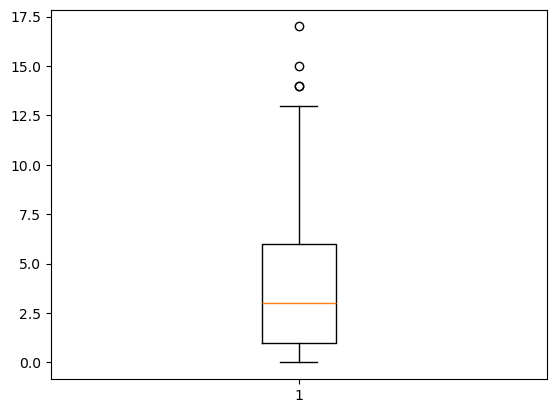

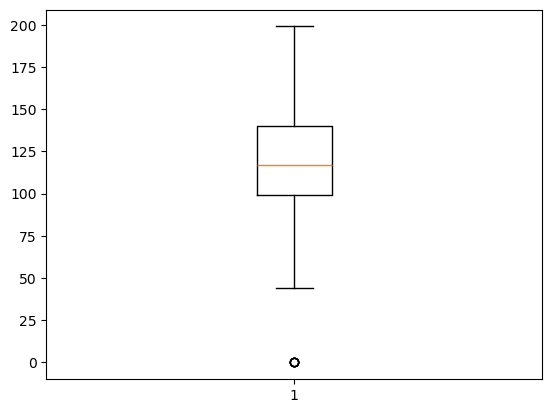

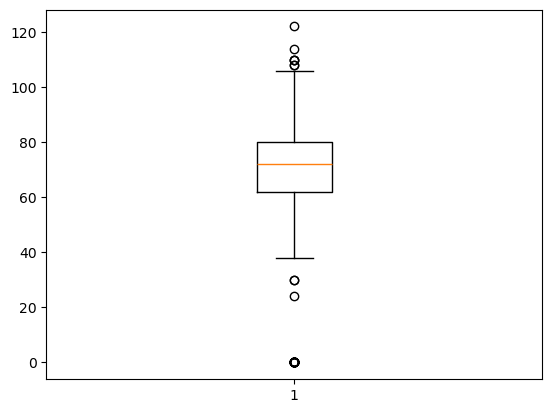

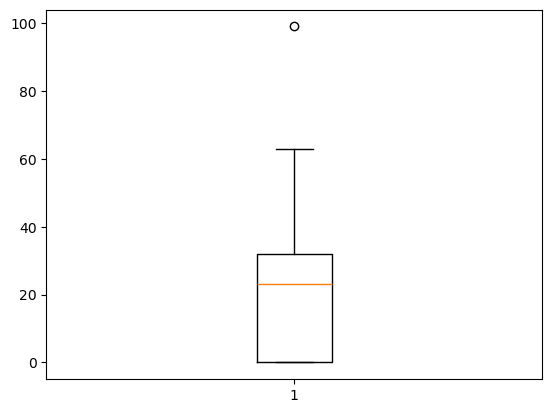

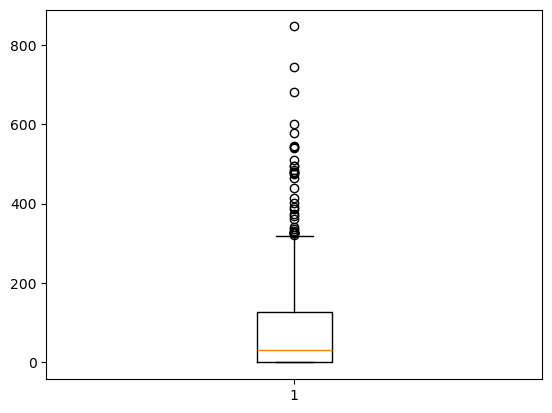

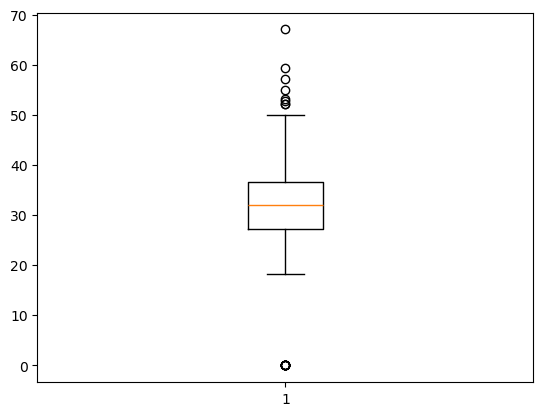

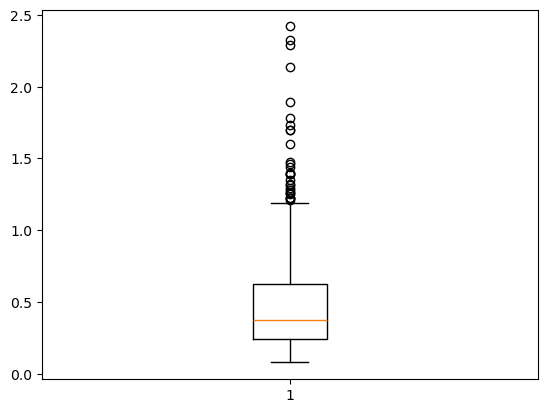

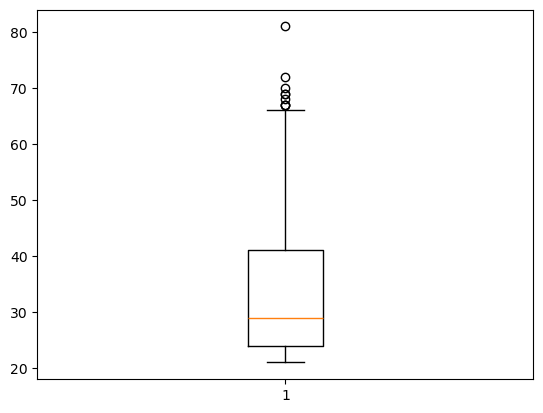

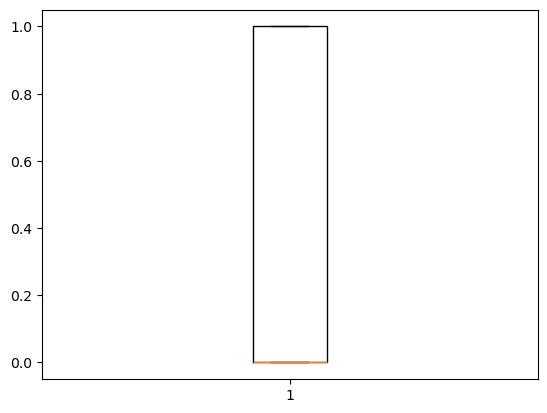

In [9]:
col=df.columns
for i in col:
    plt.boxplot(df[i])
    plt.show()

# 4. Data Preprocessing

- Separated features (x) and target (y)
- Train-test split (80-20)
- Applied feature scaling using StandardScaler

In [10]:
x=df.drop('Outcome',axis=1)
y=df['Outcome']

In [11]:
cols = ['Glucose','BMI','BloodPressure','SkinThickness','Insulin']
for col in cols:
    x[col]=x[col].replace(0,x[col].median())

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

## 5.1 Logistic Regression

Logistic Regression was used as a baseline model.

Advantages:
- Simple and interpretable
- Works well for binary classification
- Provides probability outputs (useful for threshold tuning)

In [17]:
from sklearn.base import BaseEstimator,TransformerMixin
class OutlierHandler(BaseEstimator,TransformerMixin):
    def fit(self,x,y=None):
        self.q1=np.percentile(x,25,axis=0)
        self.q3=np.percentile(x,75,axis=0)
        self.IQR=self.q3-self.q1
        return self
    def transform(self,x):
        lower=self.q1-1.5*self.IQR
        upper=self.q3+1.5*self.IQR
        return np.clip(x,lower,upper)

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
model_pipeline=Pipeline([('Imputer',SimpleImputer(strategy='median')),
                        ('Scaler',StandardScaler()),
                        ('Outlier',OutlierHandler()),
                        ('Model',LogisticRegression(class_weight='balanced',max_iter=1000))])
model_pipeline

Pipeline(steps=[('Imputer', SimpleImputer(strategy='median')),
                ('Scaler', StandardScaler()), ('Outlier', OutlierHandler()),
                ('Model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [21]:
model_pipeline.fit(x_train,y_train)

Pipeline(steps=[('Imputer', SimpleImputer(strategy='median')),
                ('Scaler', StandardScaler()), ('Outlier', OutlierHandler()),
                ('Model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [23]:
y_pred=model_pipeline.predict(x_test)

In [25]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,roc_auc_score,f1_score
y_prob1=model_pipeline.predict_proba(x_test)[:,1]
y_pred_new1=(y_prob1>=0.4).astype('int')

In [27]:
recall_score(y_test,y_pred_new1)

0.8

In [29]:
precision_score(y_test,y_pred_new1)

0.5238095238095238

In [31]:
from sklearn.model_selection import cross_val_score,KFold,GridSearchCV
fold=KFold(n_splits=5,shuffle=True,random_state=42)
cross=cross_val_score(model_pipeline,x,y,cv=fold,scoring='roc_auc')
cross

array([0.81652893, 0.82958839, 0.82125859, 0.87093537, 0.84591652])

In [33]:
cross.mean()

0.8368455578117804

In [35]:
f1_score(y_test,y_pred)

0.6129032258064516

In [37]:
x['BMI_Age'] = x['BMI'] * x['Age']
x['Glucose_BMI'] = x['Glucose'] * x['BMI']

# 5.2 Hyperparameter Tuning

Used GridSearchCV to tune hyperparameters 
such as regularization strength (C).

This improved model performance.

In [39]:
params={
    'Model__C':[0.10,0.3,10,0.5,0.2],
    'Model__solver':['lbfgs'],
    'Model__penalty':['l2'],
}
grid=GridSearchCV(model_pipeline,
                 params,cv=5)
grid.fit(x,y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('Imputer',
                                        SimpleImputer(strategy='median')),
                                       ('Scaler', StandardScaler()),
                                       ('Outlier', OutlierHandler()),
                                       ('Model',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000))]),
             param_grid={'Model__C': [0.1, 0.3, 10, 0.5, 0.2],
                         'Model__penalty': ['l2'], 'Model__solver': ['lbfgs']})

In [41]:
grid.best_params_

{'Model__C': 0.3, 'Model__penalty': 'l2', 'Model__solver': 'lbfgs'}

In [43]:
grid.best_score_

0.7540022069433834

## 6. Random Forest

Random Forest is an ensemble learning method based on multiple decision trees.

Advantages:
- Handles non-linear relationships
- Reduces overfitting using bagging
- Often performs better on complex datasets

In [45]:
model_pipeline1=Pipeline([('Iputer',SimpleImputer(strategy='median')),
                        ('Outlier',OutlierHandler()),
                        ('Model',RandomForestClassifier(n_estimators=300,
                                                        max_depth=6,             
                                                        min_samples_split=8,
                                                        min_samples_leaf=4,
                                                        max_features='sqrt',
                                                        class_weight='balanced',
                                                        random_state=42))])
model_pipeline1

Pipeline(steps=[('Iputer', SimpleImputer(strategy='median')),
                ('Outlier', OutlierHandler()),
                ('Model',
                 RandomForestClassifier(class_weight='balanced', max_depth=6,
                                        min_samples_leaf=4, min_samples_split=8,
                                        n_estimators=300, random_state=42))])

In [47]:
model_pipeline1.fit(x_train,y_train)

Pipeline(steps=[('Iputer', SimpleImputer(strategy='median')),
                ('Outlier', OutlierHandler()),
                ('Model',
                 RandomForestClassifier(class_weight='balanced', max_depth=6,
                                        min_samples_leaf=4, min_samples_split=8,
                                        n_estimators=300, random_state=42))])

In [49]:
y_pred1=model_pipeline.predict(x_test)

In [51]:
y_prob=model_pipeline1.predict_proba(x_test)[:,1]
y_pred_new=(y_prob>=0.4).astype('int')

In [53]:
recall_score(y_test,y_pred_new)

0.8363636363636363

In [55]:
fold1=KFold(n_splits=5,shuffle=True,random_state=42)
cross1=cross_val_score(model_pipeline1,x,y,cv=fold,scoring='roc_auc')
cross1

array([0.82883379, 0.84191688, 0.84999119, 0.85989562, 0.83593466])

In [56]:
cross1.mean()

0.8433144298738707

In [69]:
f1_score(y_test,y_pred_new)

0.6865671641791045

# 7. Model Comparison

Both Logistic Regression and Random Forest were trained and evaluated.

Logistic Regression:
- Precision: 0.52
- Recall: 0.83
- cross_validation_score: 0.83
- F1 Score: 0.61

Random Forest:
- Recall: 0.83
- cross_validation_score: 0.84
- F1 Score: 0.68

Observation:

Logistic Regression provides better interpretability and stable performance.

Random Forest may improve overall accuracy but may not significantly 
increase recall.

Since this is a medical diagnosis problem, Recall is prioritized 
to reduce false negatives.

Final Model Selection:
After comparing Logistic Regression and Random Forest, 
both models achieved similar Recall (0.83), which is important 
for minimizing false negatives in medical diagnosis.

However, Random Forest achieved a higher F1-score (0.68) 
and slightly better cross-validation performance (0.84).

Therefore, Random Forest was selected as the final model 
due to its better overall balance between precision and recall 
while maintaining strong recall performance.